[Domain 1] Beta=0.0510, A=0.0672, Loss=0.000151


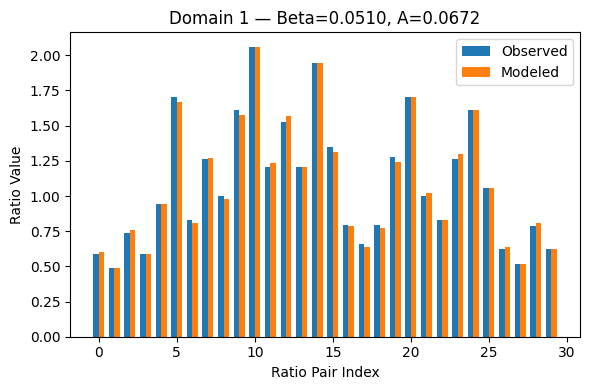

[Domain 2] Beta=0.0430, A=0.1699, Loss=0.000472


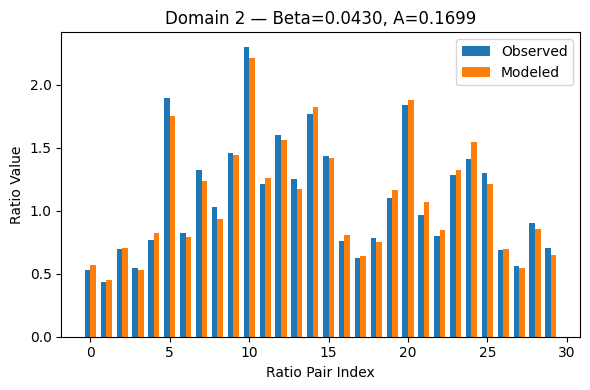

[Domain 3] Beta=0.0439, A=0.1601, Loss=0.000147


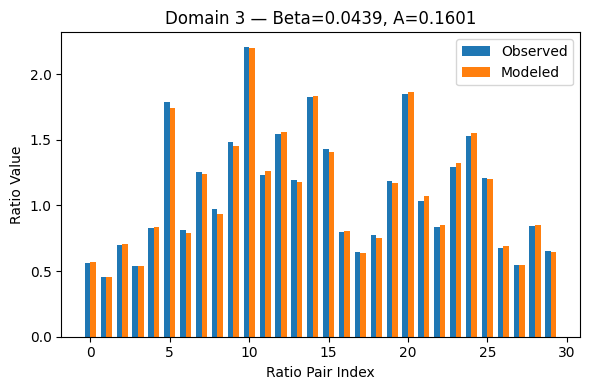

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, Bounds, BFGS
from itertools import permutations

base_token = 0.66
N = 3 * base_token
x_vals = np.array([i * base_token for i in (1 / 3, 1 / 2, 1, 2, 3)])

lyst = [
    [2.3344510239838225, 2.332892905356599, 2.305486517203082, 2.261286674352709, 2.251291523597417],
    [2.3217512425787867, 2.315506112513719, 2.305486517203082, 2.2779459045407386, 2.2546816253283204],
    [2.316531607957455, 2.307071547605066, 2.305486517203082, 2.2700898714762863, 2.2531400735499223],
]


def difference_model(Ni, Nj, beta, A):
    return (Ni + A) ** (-beta) - (Nj + A) ** (-beta)


def huber_loss(r, delta=0.001):
    abs_r = abs(r)
    if abs_r <= delta:
        return 0.5 * r**2
    return delta * (abs_r - 0.5 * delta)


def multi_ratio_objective(ba, Lvals, Nvals, ratio_pairs, use_log_ratio=False, use_huber=False, delta=1.0):
    beta, A = ba
    total_loss = 0.0

    for (num_pair, den_pair) in ratio_pairs:
        i, j = num_pair[0] - 1, num_pair[1] - 1
        k, m = den_pair[0] - 1, den_pair[1] - 1

        obs_num = Lvals[i] - Lvals[j]
        obs_den = Lvals[k] - Lvals[m]
        if abs(obs_den) < 1e-12:
            continue

        mod_num = difference_model(Nvals[i], Nvals[j], beta, A)
        mod_den = difference_model(Nvals[k], Nvals[m], beta, A)
        if abs(mod_den) < 1e-8:
            continue

        if use_log_ratio:
            if min(obs_num, obs_den, mod_num, mod_den) <= 0:
                continue
            diff = np.log(obs_num) / np.log(obs_den) - np.log(mod_num) / np.log(mod_den)
        else:
            diff = obs_num / obs_den - mod_num / mod_den

        total_loss += huber_loss(diff, delta=delta) if use_huber else diff**2

    return total_loss


def generate_all_ratio_pairs(base_pairs):
    return [pair for pair in permutations(base_pairs, 2) if pair[0] != pair[1]]


def estimate_beta_and_A(Lvals, Nvals, use_log_ratio=False, use_huber=True, delta=1.0):
    base_pairs = [(1, 3), (1, 4), (1, 5), (2, 4), (2, 5), (3, 5)]
    ratio_pairs = generate_all_ratio_pairs(base_pairs)

    def obj(ba):
        return multi_ratio_objective(
            ba,
            Lvals,
            Nvals,
            ratio_pairs,
            use_log_ratio=use_log_ratio,
            use_huber=use_huber,
            delta=delta,
        )

    bounds = Bounds([0, 0], [np.inf, (2.0 / 3.0) * N])
    init_guess = [0.5, 0.5]
    res = minimize(
        obj,
        x0=init_guess,
        method="trust-constr",
        bounds=bounds,
        jac="2-point",
        hess=BFGS(),
        options={"verbose": 0, "maxiter": 1000},
    )

    if res.success:
        return res.x[0], res.x[1], res.fun, ratio_pairs
    return None, None, None, ratio_pairs


def plot_ratios(domain_index, beta, A, Lvals, Nvals, ratio_pairs):
    obs_list = []
    mod_list = []

    for (num_pair, den_pair) in ratio_pairs:
        i, j = num_pair[0] - 1, num_pair[1] - 1
        k, m = den_pair[0] - 1, den_pair[1] - 1

        obs_num = Lvals[i] - Lvals[j]
        obs_den = Lvals[k] - Lvals[m]
        if abs(obs_den) < 1e-8:
            continue

        mod_num = difference_model(Nvals[i], Nvals[j], beta, A)
        mod_den = difference_model(Nvals[k], Nvals[m], beta, A)
        if abs(mod_den) < 1e-8:
            continue

        obs_list.append(obs_num / obs_den)
        mod_list.append(mod_num / mod_den)

    x_idx = np.arange(len(obs_list))
    width = 0.35

    plt.figure(figsize=(6, 4))
    plt.bar(x_idx - width / 2, obs_list, width=width, label="Observed")
    plt.bar(x_idx + width / 2, mod_list, width=width, label="Modeled")

    plt.title(f"Domain {domain_index} — Beta={beta:.4f}, A={A:.4f}")
    plt.xlabel("Ratio Pair Index")
    plt.ylabel("Ratio Value")
    plt.legend()
    plt.tight_layout()
    plt.show()


USE_LOG_RATIO = True
USE_HUBER_LOSS = True
DELTA = 0.001

for domain_index, Lvals_raw in enumerate(lyst, start=1):
    Lvals = np.array(Lvals_raw)

    beta_est, A_est, total_loss, ratio_pairs = estimate_beta_and_A(
        Lvals,
        x_vals,
        use_log_ratio=USE_LOG_RATIO,
        use_huber=USE_HUBER_LOSS,
        delta=DELTA,
    )

    if beta_est is None:
        print(f"[Domain {domain_index}] Beta/A fitting failed")
        continue

    print(f"[Domain {domain_index}] Beta={beta_est:.4f}, A={A_est:.4f}, Loss={total_loss:.6f}")
    plot_ratios(domain_index, beta_est, A_est, Lvals, x_vals, ratio_pairs)